# MTSamples EDA — FaithfulMed (Google 2D)

Owner: Isabella Rios | September milestone, Task #1

**What this notebook is for.** MTSamples is our **source-document corpus** the clinical
text the pipeline actually simplifies. Unlike MedAESQA, it carries no human faithfulness
labels, so this EDA is scoped differently:

1. **Extractor owner** — internal document structure (section headers like `SUBJECTIVE:`),
   de-identification artifacts, and how consistent the format is across specialties.
2. **Simplifier owner** — baseline readability and jargon density of the raw text. This is
   the "before" number the whole pipeline is trying to move.
3. **Everyone** — specialty coverage, so we know which document types the September
   50-example baseline set should sample from.

**Output of this notebook:** `mtsamples_specialty_counts.csv` and
`mtsamples_readability_sample.csv` — the artifacts the rest of the team consumes.

> This notebook expects the Kaggle export of MTSamples (`mtsamples.csv`, columns:
> `description`, `medical_specialty`, `sample_name`, `transcription`, `keywords`). Confirm
> these match your download in Section 1 before trusting anything downstream.

## 0. Setup

In [1]:
!pip install -q textstat pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.0 MB/s eta 0:00:00


In [2]:
import re, hashlib, collections
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textstat

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

# In Colab: upload mtsamples.csv (from the Kaggle "mtsamples" archive) into the file
# browser, or mount Drive and point DATA_PATH there.
DATA_PATH = Path("mtsamples.csv")

df = pd.read_csv(DATA_PATH)
# The Kaggle export includes a stray index column — drop it if present.
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
print(df.shape)

(4999, 5)


In [3]:
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

## 1. Schema inventory

Do not skip this. Confirm the real column names and missingness before writing any
analysis code below — everything downstream assumes these are right.

In [4]:
print("Columns:", list(df.columns))
print()
print("Dtypes:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())

Columns: ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Dtypes:
description          object
medical_specialty    object
sample_name          object
transcription        object
keywords             object
dtype: object

Missing values per column:
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


In [6]:
df.head(2)

,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with complaint of allergies.,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female presents with complaint of allergies. She used to have allergies when s...","allergy / immunology, allergic rhinitis, allergies, asthma, nasal sprays, rhinitis, nasal, erythematous, allegra, sp..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climbing stairs, difficulty with airline seats, tying shoes, used to public...","bariatrics, laparoscopic gastric bypass, weight loss programs, gastric bypass, atkin's diet, weight watcher's, body ..."


## 2. Specialty distribution

Why this matters: our September baseline set (~50 hand-curated examples) and later test
runs should sample deliberately, not just take whatever's most common. If one specialty
dominates, that's a coverage gap worth naming in the report.

In [7]:
specialty_counts = df["medical_specialty"].str.strip().value_counts()
print(f"{specialty_counts.shape[0]} distinct specialties")
specialty_counts.head(15)

40 distinct specialties


,count
medical_specialty,
Surgery,1103
Consult - History and Phy.,516
Cardiovascular / Pulmonary,372
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,230
Neurology,223
SOAP / Chart / Progress Notes,166


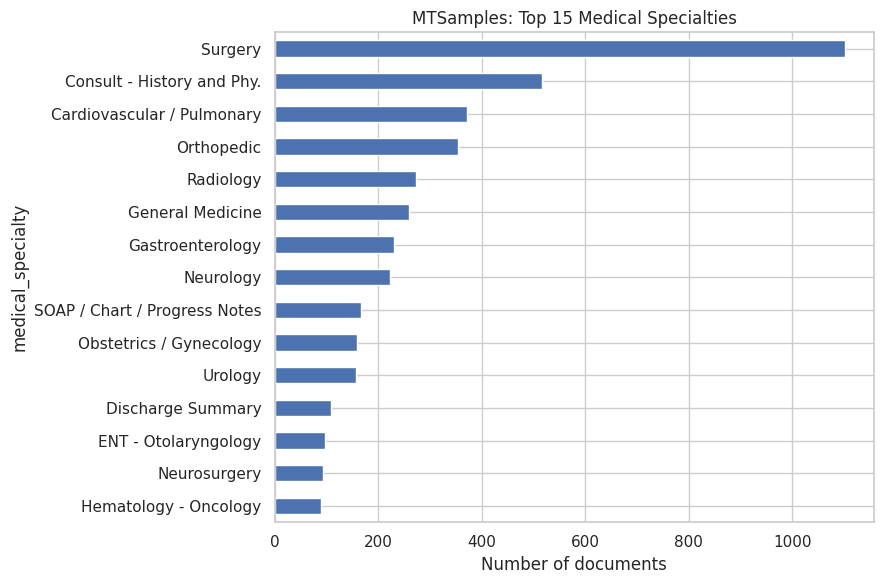

Top 5 specialties account for 52.4% of all documents


In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
specialty_counts.head(15).plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Number of documents")
ax.set_title("MTSamples: Top 15 Medical Specialties")
plt.tight_layout()
plt.show()

top5_share = specialty_counts.head(5).sum() / specialty_counts.sum()
print(f"Top 5 specialties account for {top5_share:.1%} of all documents")

## 3. Document length and internal structure

MTSamples transcriptions are dictated notes, so most carry internal section headers
(`SUBJECTIVE:`, `HISTORY OF PRESENT ILLNESS:`, `PLAN:`, etc.). Knowing which headers recur
tells the **Extractor owner** what structural cues to prompt on, rather than treating each
document as an undifferentiated block of text.

count    4966.0
mean      465.4
std       316.4
min         1.0
25%       241.0
50%       398.0
75%       615.0
max      3029.0
Name: transcription, dtype: float64


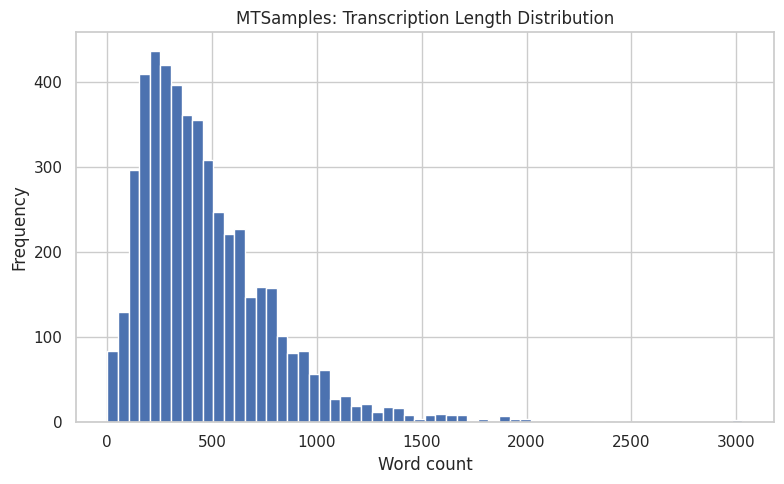

In [9]:
text = df["transcription"].dropna()
word_counts = text.str.split().str.len()
print(word_counts.describe().round(1))

fig, ax = plt.subplots(figsize=(8, 5))
word_counts.plot(kind="hist", bins=60, ax=ax)
ax.set_xlabel("Word count")
ax.set_title("MTSamples: Transcription Length Distribution")
plt.tight_layout()
plt.show()

In [10]:
# Section headers in this corpus look like "WORDS:" or "WORDS IN CAPS:,{ }" at the start
# of a clause. Pull the most common ones so the Extractor owner has a real header
# vocabulary rather than guessing.
header_pattern = re.compile(r'([A-Z][A-Z /]{3,40}):')
header_counts = collections.Counter()
for t in text.sample(min(1500, len(text)), random_state=42):
    header_counts.update(h.strip() for h in header_pattern.findall(t))

headers_df = pd.Series(header_counts).sort_values(ascending=False)
print(f"{len(headers_df)} distinct header-like strings found in a 1500-doc sample")
headers_df.head(20).to_frame("count")

1168 distinct header-like strings found in a 1500-doc sample


,count
ANESTHESIA,407
PROCEDURE,403
PREOPERATIVE DIAGNOSIS,364
POSTOPERATIVE DIAGNOSIS,331
HISTORY OF PRESENT ILLNESS,284
ALLERGIES,261
IMPRESSION,256
PHYSICAL EXAMINATION,256
HEENT,247
COMPLICATIONS,229


## 4. Baseline readability — the headline number

**The number to pull out of this section:** the Flesch-Kincaid grade level of the raw
transcriptions. Our success criterion is 80% of *pipeline outputs* at grade 8 or below —
this shows how far above that line the untouched source text sits, which is the
motivating stat for the whole project.

In [11]:
def fk_metrics(t: str) -> dict:
    words = t.split()
    if len(words) < 5:
        return {"fk_grade": np.nan, "smog": np.nan, "jargon_density": np.nan, "n_words": len(words)}
    return {
        "fk_grade": textstat.flesch_kincaid_grade(t),
        "smog": textstat.smog_index(t),
        "jargon_density": textstat.difficult_words(t) / max(len(words), 1),
        "n_words": len(words),
    }

sample = text.sample(min(300, len(text)), random_state=42)
readability = pd.DataFrame([fk_metrics(t) for t in sample])
readability.describe().round(2)

,fk_grade,smog,jargon_density,n_words
count,299.00,299.00,299.00,300.00
mean,10.30,12.28,0.27,450.96
std,2.29,1.37,0.07,302.32
min,4.71,8.72,0.10,3.00
25%,9.04,11.41,0.23,244.50
50%,10.16,12.19,0.26,374.00
75%,11.35,13.24,0.31,608.00
max,33.56,15.90,0.80,2019.00


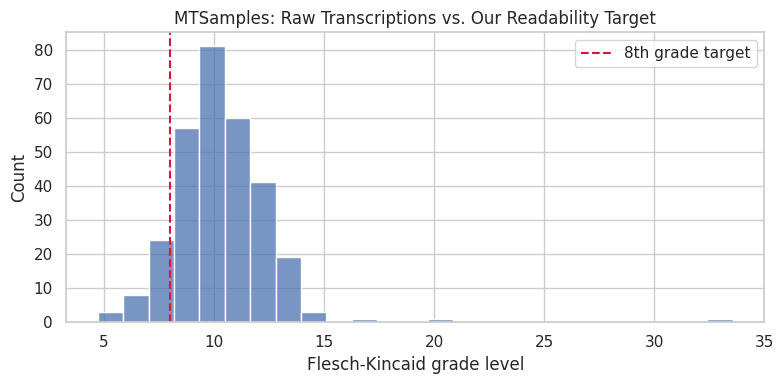

90.3% of sampled documents sit above the grade-8 target as written


In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(readability["fk_grade"].dropna(), bins=25, ax=ax)
ax.axvline(8, color="crimson", ls="--", label="8th grade target")
ax.set_xlabel("Flesch-Kincaid grade level")
ax.set_title("MTSamples: Raw Transcriptions vs. Our Readability Target")
ax.legend()
plt.tight_layout()
plt.show()

above_target = (readability["fk_grade"] > 8).mean()
print(f"{above_target:.1%} of sampled documents sit above the grade-8 target as written")

## 5. Data quality checks

De-identified dictation carries specific artifacts (redaction placeholders, dictation
fillers) that can confuse the Extractor if it isn't warned about them, plus the usual
duplicate/empty-row checks.

**Flag this one to the team immediately:** this Kaggle mirror is not 4,999 unique
documents. A large share of rows share byte-identical `transcription` text (same
template note filed under different `sample_name`/`description` pairs). Any per-document
analysis — specialty counts, length stats, the September baseline sample — needs to
decide up front whether to dedupe on `transcription`, or the counts above are inflated by
however many templates got reused.

In [13]:
n_unique = df["transcription"].nunique()
n_total = len(df)
print(f"Unique transcriptions: {n_unique} / {n_total} rows ({n_unique/n_total:.1%} unique)")

dupe_counts = df["transcription"].value_counts()
n_dupe_groups = (dupe_counts > 1).sum()
n_rows_in_dupe_groups = dupe_counts[dupe_counts > 1].sum()
print(f"{n_dupe_groups} distinct texts each appear more than once, "
      f"accounting for {n_rows_in_dupe_groups} of {n_total} rows")

redaction_pattern = re.compile(r'\bX{2,}\b')
has_redaction = text.str.contains(redaction_pattern)
print(f"\nDocuments containing redaction placeholders (e.g. 'XXXX'): {has_redaction.sum()} "
      f"({has_redaction.mean():.1%})")

empty_or_missing = df["transcription"].isna() | (df["transcription"].str.strip() == "")
print(f"Empty/missing transcriptions: {empty_or_missing.sum()} ({empty_or_missing.mean():.1%})")

missing_keywords = df["keywords"].isna().mean()
print(f"Rows missing the keywords field: {missing_keywords:.1%}")

Unique transcriptions: 2357 / 4999 rows (47.1% unique)
2150 distinct texts each appear more than once, accounting for 4759 of 4999 rows

Documents containing redaction placeholders (e.g. 'XXXX'): 67 (1.3%)
Empty/missing transcriptions: 33 (0.7%)
Rows missing the keywords field: 21.4%


### 5a. How much of each specialty's row count is real?

Section 2 ranked specialties by raw row count. But we now know almost half the dataset
is duplicate text, and unevenly so, this chart re-checks that ranking against how much
of each specialty's total is actually unique documents vs. copies of the same template.
A stacked bar is the right shape here because unique + duplicate always sum exactly to
the raw count for that specialty, it's a part-of-whole relationship, not two separate
measurements.

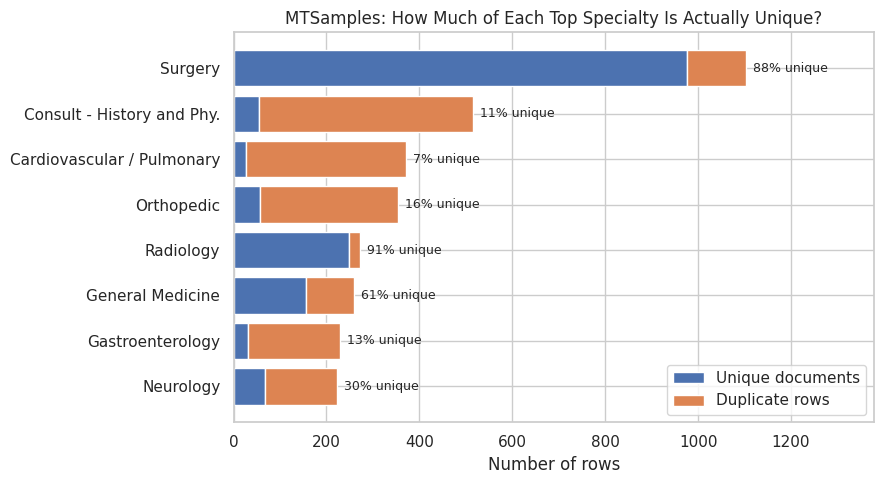

,raw rows,unique docs,pct_unique
medical_specialty,,,
Surgery,1103,976,88.0
Consult - History and Phy.,516,55,11.0
Cardiovascular / Pulmonary,372,26,7.0
Orthopedic,355,56,16.0
Radiology,273,248,91.0
General Medicine,259,157,61.0
Gastroenterology,230,31,13.0
Neurology,223,67,30.0


In [14]:
top8 = specialty_counts.head(8).index
dedup_counts = (
    df.drop_duplicates(subset="transcription")
      ["medical_specialty"].str.strip()
      .value_counts()
      .reindex(top8, fill_value=0)
)
raw_counts = specialty_counts.loc[top8]
dup_counts = raw_counts - dedup_counts
pct_unique = (dedup_counts / raw_counts * 100).round(0)

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(top8))
ax.barh(y, dedup_counts, color="#4C72B0", label="Unique documents")
ax.barh(y, dup_counts, left=dedup_counts, color="#DD8452", label="Duplicate rows")

for i, (raw, pct) in enumerate(zip(raw_counts, pct_unique)):
    ax.text(raw + 15, i, f"{pct:.0f}% unique", va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(top8)
ax.invert_yaxis()
ax.set_xlabel("Number of rows")
ax.set_title("MTSamples: How Much of Each Top Specialty Is Actually Unique?")
ax.legend(loc="lower right")
ax.set_xlim(0, raw_counts.max() * 1.25)
plt.tight_layout()
plt.show()

pd.DataFrame({"raw rows": raw_counts, "unique docs": dedup_counts, "pct_unique": pct_unique})

## 6. Keyword field — a cheap vocabulary proxy

No gold jargon list exists for MTSamples, so the author-supplied `keywords` field is the
closest thing to a topic/vocabulary signal we get for free. Useful for spot-checking
whether the Simplifier's plain-language substitutions are covering the terms that
actually recur.

In [15]:
kw = df["keywords"].dropna().str.split(",")
flat_kw = [k.strip().lower() for row in kw for k in row if k.strip()]
kw_counts = pd.Series(collections.Counter(flat_kw)).sort_values(ascending=False)
print(f"{len(kw_counts)} distinct keywords across {len(kw)} documents with a keywords field")
kw_counts.head(20).to_frame("count")

10380 distinct keywords across 3931 documents with a keywords field


,count
surgery,1043
orthopedic,307
cardiovascular / pulmonary,277
: thesetranscribed medical transcription sample reports and examples are provided by various users andare for reference purpose only. mthelpline does not certify accuracy and quality of sample reports.these transcribed medical transcription sample reports may include some uncommon or unusual formats;this would be due to the preference of the dictating physician. all names and dates have beenchanged (or removed) to keep confidentiality. any resemblance of any type of name or date orplace or anything else to real world is purely incidental.,253
radiology,250
consult - history and phy.,220
gastroenterology,199
neurology,165
urology,145
general medicine,143


## 7. Manual read

Stats won't catch everything. Pull a handful of documents across different specialties
and actually read them, look for dictation artifacts, inconsistent headers, or anything
that would trip up the Extractor.

In [16]:
for specialty in specialty_counts.head(5).index:
    row = df[df["medical_specialty"].str.strip() == specialty].sample(1, random_state=1).iloc[0]
    print("=" * 70)
    print(f"SPECIALTY: {specialty}  |  SAMPLE: {row['sample_name']}")
    print("=" * 70)
    print(str(row["transcription"])[:600], "...\n")

SPECIALTY: Surgery  |  SAMPLE:  Skull Base Reconstruction 
PREOPERATIVE DIAGNOSIS:,  Squamous cell carcinoma of right temporal bone/middle ear space.,POSTOPERATIVE DIAGNOSIS: , Squamous cell carcinoma of right temporal bone/middle ear space.,PROCEDURE: , Right temporal bone resection; rectus abdominis myocutaneous free flap for reconstruction of skull base defect; right selective neck dissection zones 2 and 3.,ANESTHESIA: , General endotracheal.,DESCRIPTION OF PROCEDURE:  ,The patient was brought into the operating room, placed on the table in supine position.  General endotracheal anesthesia was obtained in the usual fashion.  The Neurosurgery team p ...

SPECIALTY: Consult - History and Phy.  |  SAMPLE:  Glioblastoma Multiforme - Consult 
REASON FOR CONSULTATION: , We were asked to see the patient in regards to a brain tumor.,HISTORY OF PRESENT ILLNESS: ,She was initially diagnosed in September of this year with a glioblastoma multiforme.  She presented with several lesions in her br

## 8. Freeze and export

Same rule as MedAESQA: version the source file and stop editing it once the team starts
reporting numbers against it. Commit these CSVs plus the SHA-256 of the source CSV.

In [17]:
digest = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print("mtsamples.csv sha256:", digest)

specialty_counts.to_csv("mtsamples_specialty_counts.csv", header=["count"])
readability.to_csv("mtsamples_readability_sample.csv", index=False)
headers_df.to_csv("mtsamples_header_vocabulary.csv", header=["count"])

with open("mtsamples_freeze.txt", "w") as f:
    f.write("source: mtsamples.csv\n")
    f.write(f"sha256: {digest}\n")
    f.write(f"n_documents: {len(df)}\n")
    f.write(f"n_specialties: {specialty_counts.shape[0]}\n")
print("Saved: mtsamples_specialty_counts.csv, mtsamples_readability_sample.csv, "
      "mtsamples_header_vocabulary.csv, mtsamples_freeze.txt")

mtsamples.csv sha256: a92cb78569f460606661ee7da50c92305b60d0fac2be4b06c8d2de0f234612d4
Saved: mtsamples_specialty_counts.csv, mtsamples_readability_sample.csv, mtsamples_header_vocabulary.csv, mtsamples_freeze.txt


## 9. Findings summary

Numbers below are from this run against the Kaggle `mtsamples.csv`. Re-check them if the
source file changes, and add rows as you find more.

| # | Finding | Who needs it | Action |
|---|---------|--------------|--------|
| 1 | Only 47% of rows (2,357 / 4,999) have a unique `transcription` — the rest are exact duplicate template notes filed under different sample names | everyone | decide on a dedup strategy before drawing the September baseline sample or reporting any per-document stat |
| 2 | Raw transcriptions average grade ~10.3 (Flesch-Kincaid), and 90% of sampled docs sit above our grade-8 target | Simplifier | motivating stat for the report — this is the "before" number |
| 3 | Top 5 specialties (Surgery, Consult-History&Phy, Cardiovascular/Pulmonary, Orthopedic, Radiology) cover just over half of rows; 35 other specialties split the rest thinly | everyone | make sure the baseline set deliberately includes low-frequency specialties, not just what's most common |
| 4 | 1.3% of documents contain redaction placeholders (`XXXX`) | Extractor | prompt the Extractor to skip redacted spans rather than treating `XXXX` as a real value |
| 5 | Header vocabulary is dominated by ANESTHESIA, PROCEDURE, PREOPERATIVE/POSTOPERATIVE DIAGNOSIS, HISTORY OF PRESENT ILLNESS | Extractor | use these as structural anchors when designing the extraction prompt |
| 6 | 0.7% of rows have an empty/missing transcription; 21% are missing the keywords field | everyone | filter empty transcriptions before building the baseline set; don't rely on keywords being present |
| 7 | The keywords field itself isn't clean — a ~250-count "entry" is actually a boilerplate site disclaimer sentence, not a real keyword | Simplifier (if using keywords as a jargon proxy) | strip boilerplate before treating keyword frequency as a vocabulary signal |
